In [6]:
#Импорт всех нужных библиотек
import threading
import asyncio
import sys

# ← ОБЯЗАТЕЛЬНО для Windows + Jupyter + Playwright
if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

import json
import csv
import re
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright
from abc import ABC, abstractmethod

import pandas as pd
import aiohttp
import matplotlib.pyplot as plt

In [7]:
class ParserPlusPlus(ABC):
    """
    Абстрактный класс для парсеров. В будущем он поможет нам парсить другие сайты
    """
    def __init__(self):
        self._last_page: int = 0
        self._urls: list[str] = []
    
    @abstractmethod
    def _generate_url(self, num: int) -> str: pass

    def _generate_urls(self) -> list[str]:

        urls: list[str] = []

        for i in range(self._last_page):
            url: str = self._generate_url(i + 1)
            urls.append(url)
        
        self._urls = urls
        
        return urls
    
    @abstractmethod
    async def _parse_html(self, html: str) -> pd.DataFrame: pass

    async def parse(self):
        """
        Базовая функция для парсинга: создаёт задачи на скачивания html'ек, после парсит нужные вещи на каждой странице и сохраняет
        """
        async with aiohttp.ClientSession() as sess:
            tasks = [self._async_request(sess, url) for url in self._urls]
            htmls: list[str] = await asyncio.gather(*tasks)
            print(f"Скачано страниц: {len(htmls)}")
            for i, html in enumerate(htmls):
                print(f"  [{i}] длина HTML: {len(html)} символов")  # 0 = пустой ответ
                print(html[:500])
            tasks = [self._parse_html(html) for html in htmls]
            dfs: list[pd.DataFrame] = await asyncio.gather(*tasks)

            df = pd.concat(dfs, ignore_index=True)

        self.df = df
        return df
    
    @staticmethod
    async def _async_request(sess: aiohttp.ClientSession, url: str) -> str:
        async with sess.get(url, timeout=aiohttp.ClientTimeout(total=10)) as response:

          if response.status == 200:
            return await response.text()

          else:
            print(f"Ошибка {response.status} для {url}")
            return ""
    
    def to_csv(self, file_name: str):
        """ Сохраняем напаршенно в csv """
        self.df.to_csv(PATH + f"input/{file_name}.csv", index=False, encoding='utf-8-sig')
    
    @staticmethod
    def parse_quantity(text: str) -> tuple[int | None, str | None]:
        """
        Парсим единицу измерения и её значение
        Паттерн: целое число (или десятичное) + возможно пробел + единица измерения
        """
        pattern = r'(\d+(?:\.\d+)?)\s*([а-я]+)$'
        match = re.search(pattern, text.strip())
        
        if match:
            quantity_int: int = int(float(match.group(1)))  # преобразуем в int
            quantity_type: str = match.group(2)
            return quantity_int, quantity_type
        else:
            print( f"Не удалось распарсить строку: {text}" )
            return None, None
    
    @staticmethod
    def count_price(quantity_int: int, quantity_type: str, price: int | float) -> float:
        if quantity_int:

            price_real = price / quantity_int

            if quantity_type == 'мл' or quantity_type == 'г' or quantity_type == 'гр':
                price_real *= 1000

            return round( price_real, 2)

        return None

In [8]:
PATH = PATH = r"C:\Users\Артур\.vscode\НОД" + "\\"

class AvitoParser(ParserPlusPlus):
    """
    Класс для парсинга Авито и нахождения локаций. Сделан на основе абстрактного класса ParserPlusPlus 
    """
    BASE_URL = "https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam"

    def __init__(self, max_pages: int = 5):
        super().__init__() #Создаем _last_pages и _urls:
        self._last_page = max_pages #Заменяем _last_pages с 0 на установленное нами число
        self._generate_urls() #Заполняем _urls


    def _generate_url(self, page_num: int) -> str:
        """
        Создает url для каждой страринцы
        """
        url = f"{self.BASE_URL}?p={page_num}"
        return url

    async def parse(self):
        """Стандартный parse в базовом классе использует aiohttp - 
        это просто HTTP-клиент, который скачивает «сырой» HTML так же, 
        как браузер получает страницу до выполнения JavaScript. 
        Авито — современный SPA (Single Page Application): 
        при первой загрузке сервер отдаёт почти пустой HTML-скелет,
        а все объявления подгружаются JS-кодом уже в браузере. 
        aiohttp этот JS не выполняет — поэтому карточек в HTML нет. 
        Playwright запускает настоящий браузер, который выполняет JS 
        и ждёт появления карточек в DOM.
        """

        async with async_playwright() as p: #Запускаем playwright context c гарантией корректного заверешения
            browser = await p.chromium.launch(
                headless=True,
                executable_path=r"C:\Program Files\Google\Chrome\Application\chrome.exe",
                args=["--no-sandbox", "--disable-blink-features=AutomationControlled"] 
            )
            #Запускаем Chrome в фоновом режиме (headless=True).AutomationControlled скрывает признак автоматизации — без этого Авито может показать капчу.

            context = await browser.new_context(
                user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124.0.0.0 Safari/537.36",
                viewport={"width": 1366, "height": 768},
                locale="ru-RU",
            )
            #Создаём браузерный контекст — аналог нового профиля Chrome. Задаём user_agent, размер окна и локаль, чтобы имитировать реального пользователя.

            page = await context.new_page()
            await page.add_init_script(
                "Object.defineProperty(navigator, 'webdriver', {get: () => undefined});"
            )
            #Открываем новую вкладку. add_init_script выполняется до любого JS страницы — скрывает флаг navigator.webdriver, который сайты используют для детектирования ботов.

            htmls = []
            for url in self._urls:
                print(f"Парсим: {url}")
                html = await self._get_page_html(page, url)
                htmls.append(html)
                await asyncio.sleep(3)
            #Перебираем все URL последовательно (не параллельно через gather) — один браузер, одна вкладка. asyncio.sleep(3) — пауза между запросами, чтобы не триггерить антибот-защиту.

            await browser.close()

        # дальше стандартный пайплайн из базового класса
        tasks = [self._parse_html(html) for html in htmls]
        dfs: list[pd.DataFrame] = await asyncio.gather(*tasks)
        df = pd.concat(dfs, ignore_index=True)
        self.df = df
        return df

    @staticmethod
    async def _get_page_html(page, url: str) -> str:
        await page.goto(url, wait_until="domcontentloaded", timeout=60_000)
        #Открывает URL в браузере. wait_until="domcontentloaded" — ждёт момента, когда HTML-скелет загружен и построено DOM-дерево (это представление HTML-страницы в виде дерева объектов, с которым может работать JavaScript), но не ждёт выполнения всего JS и загрузки картинок. Фактически мы ждем, когда Авито подгрузит нам данные мз своих баз и начинаем парсить их
        try:
            await page.wait_for_selector('[data-marker="item"]', timeout=15_000)
            #Ждёт, пока в DOM появится хотя бы один элемент с data-marker="item" — то есть первая карточка объявления. Именно здесь мы ждём выполнения JS, который подгружает объявления. Таймаут 15 секунд — если карточки не появились, значит страница пустая или капча.
        except Exception:
            print(f"  [!] Карточки не появились на {url}")
        await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
        #Выполняет JS прямо в браузере — прокручивает страницу до самого низа. Многие сайты используют lazy loading: элементы подгружаются только когда пользователь доскроллил до них. Без этой строки нижние карточки могут отсутствовать в DOM
        await asyncio.sleep(2)
        #Пауза 2 секунды после скролла — даёт время JS подгрузить элементы, которые стали видимы после прокрутки.
        return await page.content()


    
    async def _parse_html(self, html: str) -> pd.DataFrame:
        soup = BeautifulSoup(html, "html.parser")
        items = soup.find_all("div", attrs={"data-marker": "item"}) #Список с html тэгами карточек 
        results = []
        print(f"  Найдено карточек: {len(items)}")
        for item in items:
            try:
                results.append(self._extract_listing_data(item)) #Обрабатываем содержимой html карточки
            except Exception as e:
                print(f"  [!] Ошибка карточки: {e}")
        return pd.DataFrame(results)

    def _extract_listing_data(self, item) -> dict:

        # ── Заголовок и ссылка ────────────────────────────────────────────────
        title_tag = item.find("a", attrs={"data-marker": "item-title"})
        title = ""
        link = ""
        if title_tag:
            title = title_tag.get("title", "") or title_tag.get_text(strip=True)
            href = title_tag.get("href", "")
            link = "https://www.avito.ru" + href.split("?")[0]  # убираем ?context=...

        # ── Цена ──────────────────────────────────────────────────────────────
        price_tag = item.find("meta", attrs={"itemprop": "price"})
        if price_tag:
            price = price_tag.get("content", "")
        else:
            price_block = item.find("p", attrs={"data-marker": "item-price"})
            price = price_block.get_text(strip=True) if price_block else ""

        # ── Адрес ─────────────────────────────────────────────────────────────
        street = ""
        metro = ""
        metro_time = ""

        geo_block = item.find(attrs={"data-marker": "item-address"})
        if geo_block:
            all_p = geo_block.find_all("p")

            # ── Улица: первый <p> ─────────────────────────────────────────────
            # Структура: <p><span title=""><span>иконка SVG</span>текст улицы</span></p>
            if len(all_p) >= 1:
                outer_span = all_p[0].find("span", title=True)
                if outer_span:
                    # get_text даст "текст улицы" без SVG-мусора
                    street = outer_span.get_text(strip=True)

            # ── Метро: второй <p> ─────────────────────────────────────────────
            # Структура: <p>
            #   <span class="geo-icons-...">  ← [0] иконки линий, пропускаем
            #   <span>Киевская</span>         ← [1] название станции
            #   <span>                        ← [2] содержит время
            #     <span>, </span>
            #     <span>11–15 мин.</span>
            #   </span>
            # </p>
            if len(all_p) >= 2:
                # find_all только прямых дочерних span (recursive=False)
                top_spans = all_p[1].find_all("span", recursive=False)
                # top_spans[0] — иконки (geo-icons-...), пропускаем
                # top_spans[1] — название станции
                # top_spans[2] — время (содержит вложенные span)
                if len(top_spans) >= 2:
                    metro = top_spans[1].get_text(strip=True)        # "Киевская"
                if len(top_spans) >= 3:
                    # Внутри span времени: <span>, </span><span>11–15 мин.</span>
                    time_spans = top_spans[2].find_all("span")
                    metro_time = time_spans[-1].get_text(strip=True) # "11–15 мин."

        # ── Площадь из заголовка ──────────────────────────────────────────────
        area_match = re.search(r"(\d[\d,.]*)\s*м²", title)
        area = area_match.group(0) if area_match else ""

        # ── Дата ──────────────────────────────────────────────────────────────
        date_tag = item.find("p", attrs={"data-marker": "item-date"})
        date = date_tag.get_text(strip=True) if date_tag else ""

        return {
            "title":      title,
            "price":      price,
            "area":       area,
            "address":    street,
            "metro":      metro,
            "metro_time": metro_time,
            "date":       date,
            "url":        link,
        }

    def clean(self) -> pd.DataFrame:
        """Очищает self.df: убирает пропуски, выбросы по цене и площади."""

        df = self.df.dropna()

        # Цена — приводим к int, фильтруем выбросы
        df['price'] = df['price'].apply(int)
        df = df[df['price'] < 500_000]

        # Площадь — парсим число из строки вида "45,5 м²"
        df['area'] = df['area'].apply(self._clean_area)
        df = df[df['area'] < 150]

        df = df.reset_index(drop=True)
        self.df = df
        return df

    @staticmethod
    def _clean_area(line) -> float | None:
        """Извлекает число из строки площади. Например: '45,5 м²' → 45.5"""
        if isinstance(line, float):
            return None
        try:
            return float(line.split('м')[0].replace(',', '.'))
        except ValueError:
            return None

    def plot(self) -> None:
        """Строит гистограммы распределения цен и площадей."""
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        self.df['price'].plot(
            kind='hist', bins=30, edgecolor='black', ax=axes[0]
        )
        axes[0].set_title('Распределение цен')
        axes[0].set_xlabel('Цена')
        axes[0].set_ylabel('Частота')

        self.df['area'].plot(
            kind='hist', bins=30, edgecolor='black', ax=axes[1]
        )
        axes[1].set_title('Распределение площадей')
        axes[1].set_xlabel('Площадь')
        axes[1].set_ylabel('Частота')

        plt.tight_layout()
        plt.show()

# Как устроен сбор данных
# parse
# │
# ├── Playwright: _get_page_html × N (последовательно)  ← скачиваем HTML каждой страницы
# │
# └── для каждого HTML:
#     └── _parse_html(html)
#         ├── find_all("div[data-marker=item]")
#         ├── для каждой карточки:
#         │   └── _extract_listing_data(item) → dict
#         └── pd.DataFrame(results)
#
# └── pd.concat(dfs) → единый DataFrame
    

Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=1
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=2
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=3
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=4
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=5
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=6
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=7
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=8
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=9
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=10
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=11
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=12
Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=13
Парсим: https://www.avito.ru/moskva/kommerchesk

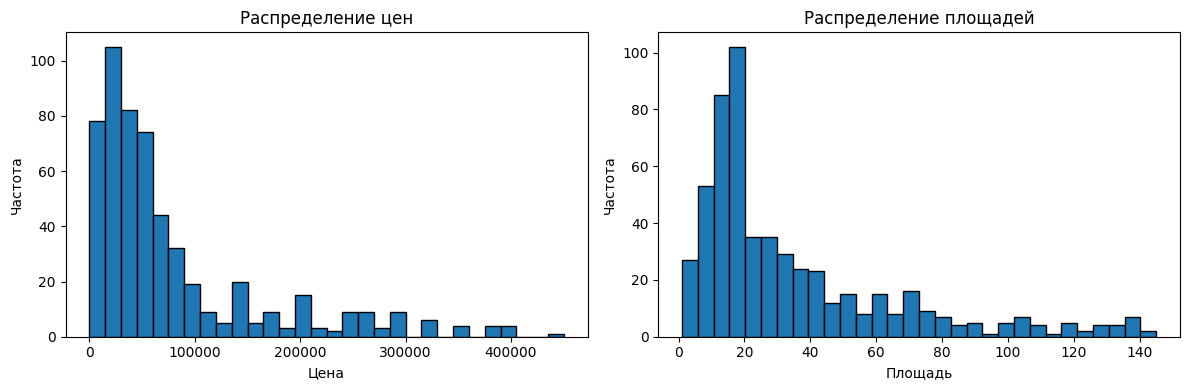

In [9]:
#Playwright запускает браузер как отдельный системный процесс (подпроцесс).
#Чтобы общаться с ним асинхронно  event loop должен уметь работать с подпроцессами на уровне ОС.
# На Windows существуют два event loop:
# SelectorEventLoop - стоит по умолчанию в Jupiter
# ProactorEventLoop - умеет работать и с сетью, и с подпроцессами

#При этом, даже если переключиться на ProactorEventLoop, 
#в Jupyter уже запущен SelectorEventLoop — и asyncio.run() не может создать новый loop поверх него:


# Jupyter
# └── SelectorEventLoop (уже запущен)
#     ├── ✗ не поддерживает подпроцессы
#     └── ✗ нельзя запустить второй loop поверх него


import nest_asyncio
nest_asyncio.apply()
import threading

def run():
    loop = asyncio.ProactorEventLoop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(parser.parse())
    loop.close()

parser = AvitoParser(max_pages=20)
#threading.Thread создаёт отдельный поток. 
#У каждого потока в Python свой event loop — Jupyter не мешает, 
#его SelectorEventLoop живёт в главном потоке и не виден из нового.
thread = threading.Thread(target=run)
thread.start()
thread.join()
print(parser.df)

parser.clean()     # очищаем данные
parser.plot()      # смотрим распределения
parser.to_csv("avito_commercial")  # сохраняем


In [19]:
import requests


class GeocoderClient:
    """
    Геокодер на основе 2GIS API.
    Принимает адрес, возвращает координаты {lon, lat}.
    """

    BASE_URL = "https://catalog.api.2gis.com/3.0/items/geocode"
    API_KEY  = "1cd5c5bf-ed6b-4539-abf3-590eab32842f" 

    def __init__(self, city: str = "Москва"):
        self._city = city

    def get_coords(self, address: str) -> dict[str, float] | None:
        params = {
            "q":      f"{self._city}, {address}",
            "fields": "items.point",
            "key":    self.API_KEY,
        }
        try:
            resp = requests.get(self.BASE_URL, params=params, timeout=10)
            data = resp.json()

            # Сначала смотрим что пришло
            if 'result' not in data:
                print(f"  [!] Нет ключа result: {data.get('meta', data)}")
                return None

            items = data['result'].get('items', [])
            if not items:
                print(f"  [!] Адрес не найден: '{address}'")
                return None

            return items[0]['point']

        except Exception as e:
            print(f"  [!] Ошибка геокодирования '{address}': {e}")
            return None

    def apply(self, df: pd.DataFrame, address_col: str = "address") -> pd.DataFrame:
        """Добавляет колонку 'coords' в датафрейм."""
        df['coords'] = df[address_col].apply(self.get_coords)
        return df


class CoverageClient:
    """
    Клиент для OpenCellID API.
    Считает количество вышек LTE в радиусе delta вокруг точки.
    """

    BASE_URL = "https://opencellid.org/cell/getInArea"
    API_KEY  = "pk.2ad54fbd1cb070f1678848ae12defabb"

    def __init__(self, delta: float = 0.005, radio: str = "LTE", mcc: int = 250):
        self._delta = delta  # ~500м в градусах
        self._radio = radio
        self._mcc   = mcc

    def get_coverage_score(self, coords: dict[str, float]) -> int:
        """Возвращает количество вышек в радиусе delta вокруг точки."""
        lon, lat = coords['lon'], coords['lat']
        d = self._delta

        params = {
            "key":    self.API_KEY,
            "BBOX":   f"{lat-d},{lon-d},{lat+d},{lon+d}",
            "format": "json",
            "radio":  self._radio,
            "mcc":    self._mcc,
        }
        try:
            resp = requests.get(self.BASE_URL, params=params, timeout=10)
            data = resp.json()
            if "error" in data:
                print(f"  [!] Ошибка API: {data}")
                return 0
            return data.get("count", 0)
        except Exception as e:
            print(f"  [!] Ошибка запроса: {e}")
            return 0

    def apply(self, df: pd.DataFrame, coords_col: str = "coords") -> pd.DataFrame:
        """Добавляет колонку 'towers_nearby' в датафрейм."""
        df['towers_nearby'] = df[coords_col].apply(
            lambda c: self.get_coverage_score(c) if c is not None else 0
        )
        return df

In [21]:
geocoder = GeocoderClient(city="Москва")
coverage = CoverageClient(delta=0.005)

df = parser.df
df = geocoder.apply(df)
df = coverage.apply(df)

df= df.dropna()

print(df)

  [!] Нет ключа result: {'api_version': '3.0.20462', 'code': 403, 'error': {'message': 'Authorization error (key is blocked, please contact api@2gis.ru)', 'type': 'apiKeyIsBlocked'}, 'issue_date': '20260522'}
  [!] Нет ключа result: {'api_version': '3.0.20462', 'code': 403, 'error': {'message': 'Authorization error (key is blocked, please contact api@2gis.ru)', 'type': 'apiKeyIsBlocked'}, 'issue_date': '20260522'}
  [!] Нет ключа result: {'api_version': '3.0.20462', 'code': 403, 'error': {'message': 'Authorization error (key is blocked, please contact api@2gis.ru)', 'type': 'apiKeyIsBlocked'}, 'issue_date': '20260522'}
  [!] Нет ключа result: {'api_version': '3.0.20462', 'code': 403, 'error': {'message': 'Authorization error (key is blocked, please contact api@2gis.ru)', 'type': 'apiKeyIsBlocked'}, 'issue_date': '20260522'}
  [!] Нет ключа result: {'api_version': '3.0.20462', 'code': 403, 'error': {'message': 'Authorization error (key is blocked, please contact api@2gis.ru)', 'type': '

In [25]:
print(len(df[df['towers_nearby'] != 0]['towers_nearby']))
df = df.dropna()
df = df[df['towers_nearby'] != 0]
print(df)

343
                                                 title   price  area  \
0    ПСН, салон, офис, бьюти, студия 65.5 м² с траф...  150000  65.5   
1                Свободного назначения, 18 м² в Москве   50000  18.0   
2    Свободного назначения, 98 м² на высоком трафик...  250000  98.0   
3               Сдам офисное помещение, 73 м² в Москве  169999  73.0   
4                        Аренда склада, 15 м² в Москве   16900  15.0   
..                                                 ...     ...   ...   
387              Свободного назначения, 29 м² в Москве    3380  29.0   
389                               Офис, 15 м² в Москве   47000  15.0   
390               Свободного назначения, 8 м² в Москве   25000   8.0   
391                               Офис, 15 м² в Москве   35000  15.0   
394  Свободного назначения, от собственника, 26 м² ...   48000  26.0   

                             address            metro  metro_time  \
0                 Ул. Михайлова, 31А          Плющево   6–10 м

In [26]:
df.to_csv(r"C:\Users\Артур\.vscode\НОД\input\avito_commercial.csv", index=False)